In [150]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## Data reading

In [128]:
#Data reading
df = pd.read_csv("taxi_trip_pricing.csv")

#Data understanding
print(df.shape)
print(df.dtypes)

df.head()

(1000, 11)
Trip_Distance_km         float64
Time_of_Day                  str
Day_of_Week                  str
Passenger_Count          float64
Traffic_Conditions           str
Weather                      str
Base_Fare                float64
Per_Km_Rate              float64
Per_Minute_Rate          float64
Trip_Duration_Minutes    float64
Trip_Price               float64
dtype: object


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


## Data quality check

### duplicate

In [129]:
#duplicate observations
duplicate_count = df.duplicated().sum()
print("Number of duplicated rows:", duplicate_count)
print("Duplicate percentage:", round(duplicate_count / len(df) * 100, 2), "%")

Number of duplicated rows: 0
Duplicate percentage: 0.0 %


### categorical values check


In [130]:
#categorical values check
categorical_columns = df.select_dtypes(include=["str"]).columns
for col in categorical_columns:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))




--- Time_of_Day ---
Time_of_Day
Afternoon    371
Morning      283
Evening      203
Night         93
NaN           50
Name: count, dtype: int64

--- Day_of_Week ---
Day_of_Week
Weekday    655
Weekend    295
NaN         50
Name: count, dtype: int64

--- Traffic_Conditions ---
Traffic_Conditions
Low       397
Medium    371
High      182
NaN        50
Name: count, dtype: int64

--- Weather ---
Weather
Clear    667
Rain     227
Snow      56
NaN       50
Name: count, dtype: int64


## Descriptive statistics

In [131]:
#Descriptive statistics
desc = df.describe().T

#add skewness
desc["Skewness"] = df.select_dtypes(include="number").skew()
#add outlier
outlier_counts = {}
for col in df.select_dtypes(include="number").columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    outlier_counts[col] = ((df[col] < lower_fence) | (df[col] > upper_fence)).sum()
desc["Outlier"] = pd.Series(outlier_counts)
#add mode
desc["Mode"] = df.mode().iloc[0]

new_column_order = [
    "count",
    "mean",
    "Mode",
    "std",
    "min",
    "25%",
    "50%",
    "75%",
    "max",
    "Skewness",
    "Outlier",
]

display(desc.reindex(columns=new_column_order))

,count,mean,Mode,std,min,25%,50%,75%,max,Skewness,Outlier
Trip_Distance_km,950.0,27.070547,3.0,19.905300,1.2300,12.63250,25.8300,38.40500,146.067047,2.236010,20
Passenger_Count,950.0,2.476842,3.0,1.102249,1.0000,1.25000,2.0000,3.00000,4.000000,0.016255,0
Base_Fare,950.0,3.502989,3.94,0.870162,2.0100,2.73000,3.5200,4.26000,5.000000,-0.005149,0
Per_Km_Rate,950.0,1.233316,0.63,0.429816,0.5000,0.86000,1.2200,1.61000,2.000000,0.079206,0
Per_Minute_Rate,950.0,0.292916,0.15,0.115592,0.1000,0.19000,0.2900,0.39000,0.500000,0.058695,0
Trip_Duration_Minutes,950.0,62.118116,89.21,32.154406,5.0100,35.88250,61.8600,89.05500,119.840000,0.017749,0
Trip_Price,951.0,56.874773,6.1269,40.469791,6.1269,33.74265,50.0745,69.09935,332.043689,3.732561,26


#### descriptive statistics graphs and plots

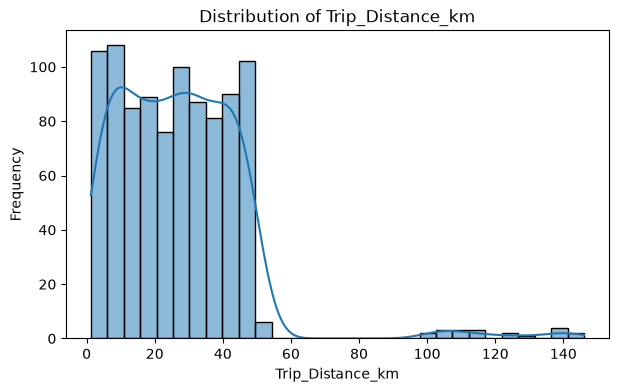

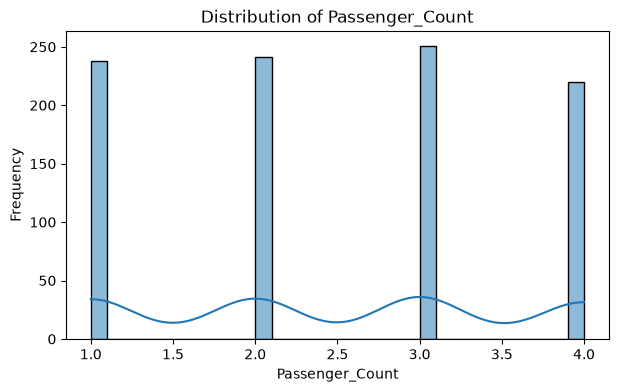

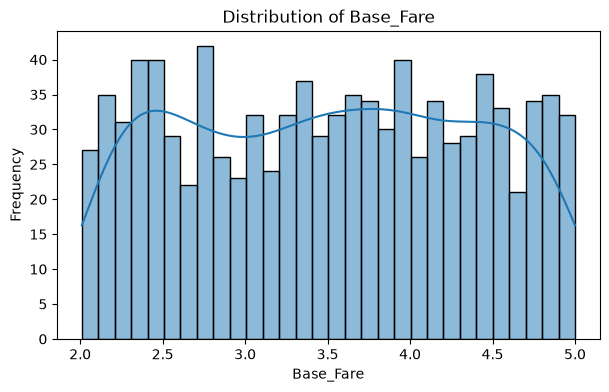

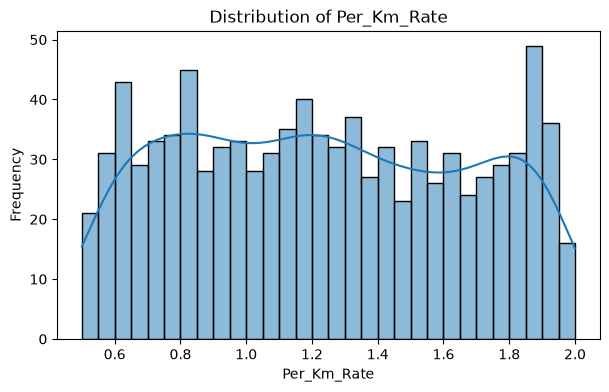

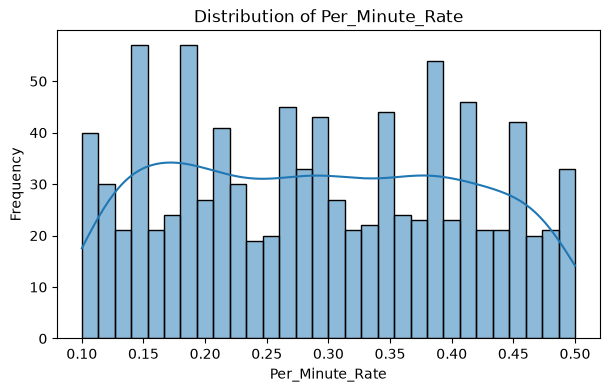

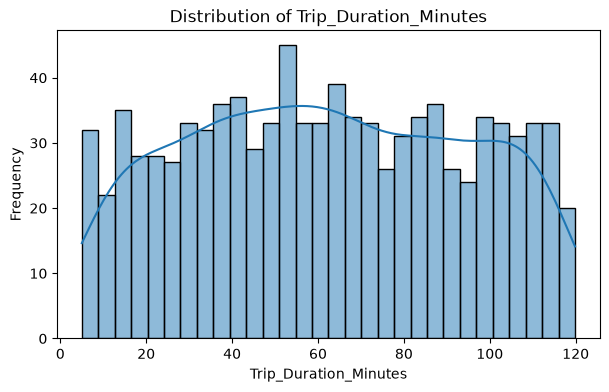

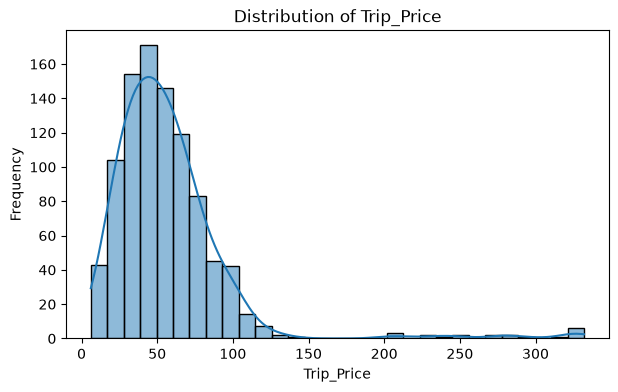

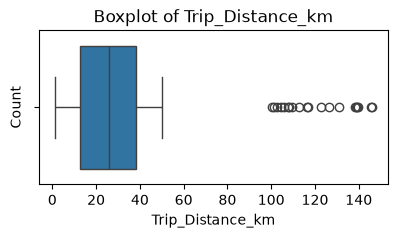

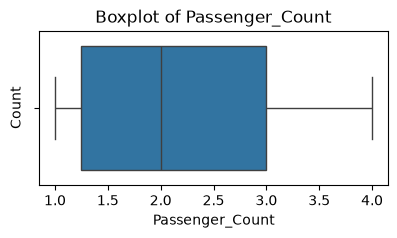

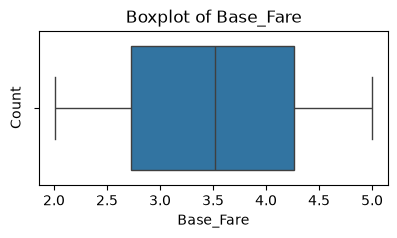

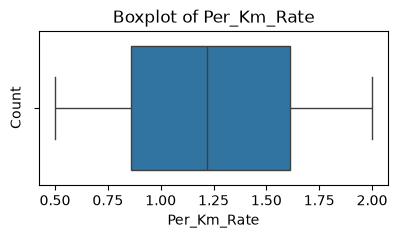

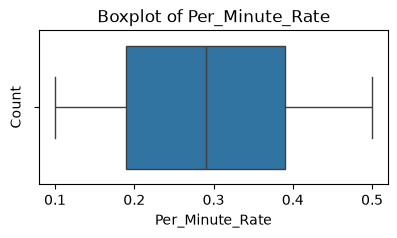

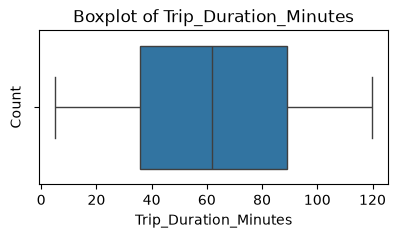

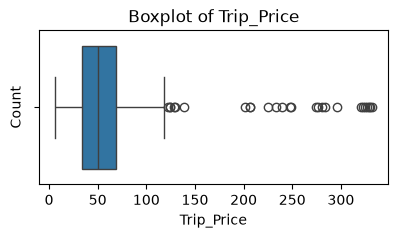

In [132]:
#descriptive statistics
#before data cleaning
numeric_cols = df.select_dtypes(include="number").columns

for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    
    sns.histplot(
        data=df,
        x=col,
        bins=30,
        kde=True
    )
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


for col in numeric_cols:
    plt.figure(figsize=(4.5, 2))
    
    sns.boxplot(
        data=df,
        x=col
    )
    
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()

Original observations: 1000
Observations used for X-Y analysis: 951
Observations excluded due to missing Trip_Price: 49


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
Trip_Distance_km,1.000,-0.045,0.033,-0.014,-0.034,-0.025,0.849
Passenger_Count,-0.045,1.000,0.029,0.044,0.044,0.018,-0.014
Base_Fare,0.033,0.029,1.000,0.001,-0.018,0.010,0.036
Per_Km_Rate,-0.014,0.044,0.001,1.000,0.026,0.030,0.275
Per_Minute_Rate,-0.034,0.044,-0.018,0.026,1.000,-0.024,0.141
Trip_Duration_Minutes,-0.025,0.018,0.010,0.030,-0.024,1.000,0.221
Trip_Price,0.849,-0.014,0.036,0.275,0.141,0.221,1.000


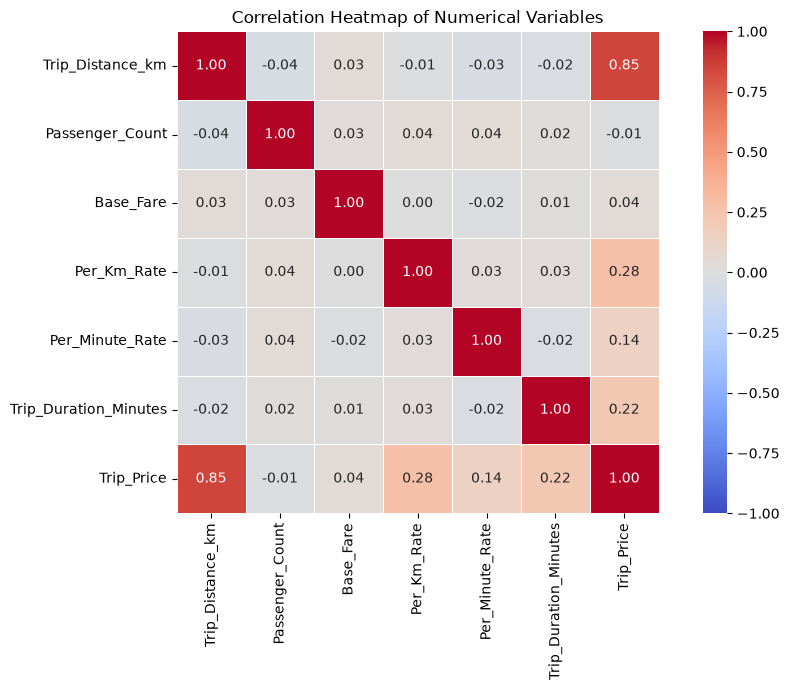

In [148]:
# Preliminary Correlation Analysis
# Use observations with available Trip_Price only

df_xy = df.loc[df["Trip_Price"].notna()].copy()

print("Original observations:", len(df))
print("Observations used for X-Y analysis:", len(df_xy))
print(
    "Observations excluded due to missing Trip_Price:",
    len(df) - len(df_xy)
)


numeric_cols = [
    "Trip_Distance_km",
    "Passenger_Count",
    "Base_Fare",
    "Per_Km_Rate",
    "Per_Minute_Rate",
    "Trip_Duration_Minutes",
    "Trip_Price"
]


#Calculate Pearson correlation matrix
corr_matrix = (
    df_xy[numeric_cols]
    .corr(method="pearson")
)

display(corr_matrix.round(3))



#Plot correlation heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,        # Show correlation coefficients
    fmt=".2f",         # Display two decimal places
    cmap="coolwarm",   # Negative = cool, positive = warm
    center=0,          # Center color scale at zero
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap of Numerical Variables"
)

plt.tight_layout()
plt.show()

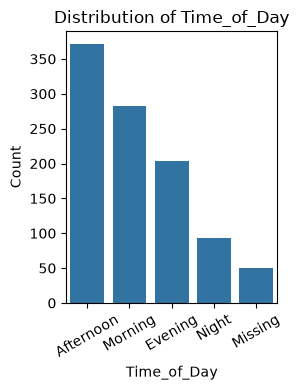

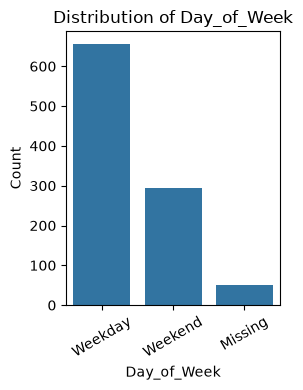

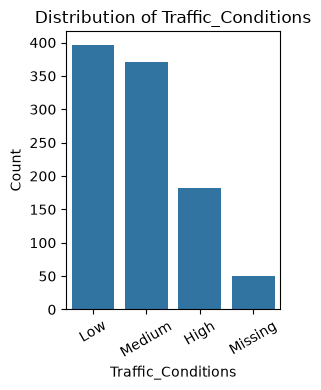

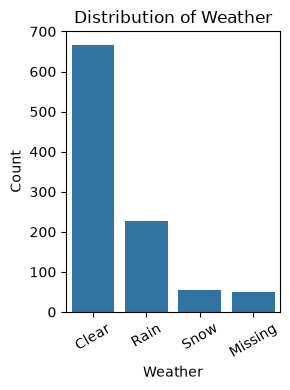

In [133]:
categorical_cols = [
    "Time_of_Day",
    "Day_of_Week",
    "Traffic_Conditions",
    "Weather"
]

for col in categorical_cols:
    plot_data = df[col].fillna("Missing")

    plt.figure(figsize=(3, 4))

    sns.countplot(
        x=plot_data,
        order=plot_data.value_counts().index
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

### outliers

In [134]:
#find outliers
price_upper_fence = df["Trip_Price"].quantile(0.75) + 1.5 * (df["Trip_Price"].quantile(0.75) - df["Trip_Price"].quantile(0.25))
distance_upper_fence = df["Trip_Distance_km"].quantile(0.75) + 1.5 * (df["Trip_Distance_km"].quantile(0.75) - df["Trip_Distance_km"].quantile(0.25))

distance_outliers = df.loc[
    df["Trip_Distance_km"] > distance_upper_fence,
    [
        "Trip_Distance_km",
        "Trip_Duration_Minutes",
        "Base_Fare",
        "Per_Km_Rate",
        "Per_Minute_Rate",
        "Trip_Price"
    ]
].sort_values("Trip_Distance_km")

price_outliers = df.loc[
    df["Trip_Price"] > price_upper_fence,
    [
        "Trip_Distance_km",
        "Trip_Duration_Minutes",
        "Base_Fare",
        "Per_Km_Rate",
        "Per_Minute_Rate",
        "Trip_Price"
    ]
].sort_values("Trip_Price")

display(distance_outliers)
display(price_outliers)

,Trip_Distance_km,Trip_Duration_Minutes,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Price
287,100.380420,89.21,4.46,NaN,NaN,329.913004
747,101.039704,56.78,4.39,1.79,NaN,283.645201
110,102.747556,53.09,2.23,1.80,0.23,274.535087
410,104.371791,89.21,3.22,1.12,0.45,206.508652
22,105.943550,23.03,3.94,1.69,0.32,201.869509
481,107.786832,79.60,2.05,1.30,0.18,322.725996
797,108.146994,97.16,2.25,NaN,0.36,239.171407
141,109.616082,53.88,4.46,1.69,0.23,327.217665
108,112.830958,78.63,3.35,1.90,0.23,233.008285
267,116.196064,19.63,2.20,0.85,0.25,206.699570


,Trip_Distance_km,Trip_Duration_Minutes,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Price
725,NaN,111.65,3.88,1.96,0.32,122.418000
411,47.550000,94.35,4.78,1.97,0.27,123.928000
522,48.530000,60.77,4.57,1.94,NaN,124.241600
751,47.050000,77.86,2.52,1.87,0.49,128.654900
671,44.940000,103.37,NaN,1.83,0.42,129.535600
795,43.730000,108.76,4.64,1.97,0.44,138.642500
22,105.943550,23.03,3.94,1.69,0.32,201.869509
410,104.371791,89.21,3.22,1.12,0.45,206.508652
267,116.196064,19.63,2.20,0.85,0.25,206.699570
835,126.547628,29.30,4.23,0.85,0.28,224.914663


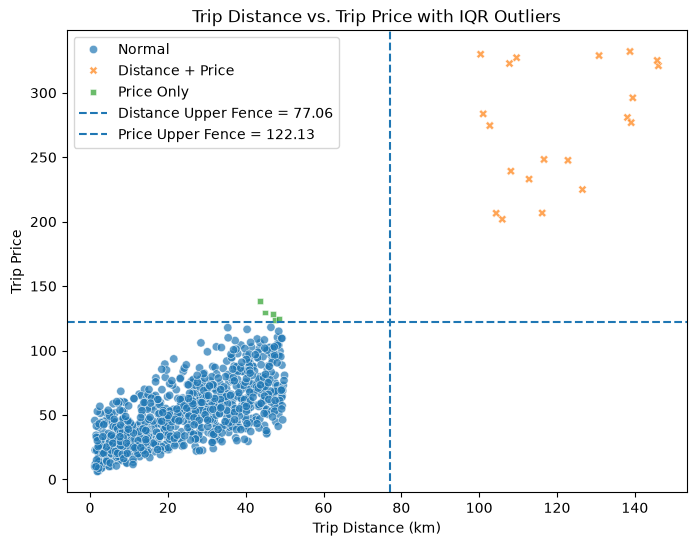

In [135]:
# Classify observations by outlier type
plot_df = df.copy()

plot_df["Outlier_Type"] = "Normal"

plot_df.loc[
    plot_df["Trip_Price"] > price_upper_fence,
    "Outlier_Type"
] = "Price Only"

plot_df.loc[
    (plot_df["Trip_Distance_km"] > distance_upper_fence) &
    (plot_df["Trip_Price"] > price_upper_fence),
    "Outlier_Type"
] = "Distance + Price"


plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=plot_df,
    x="Trip_Distance_km",
    y="Trip_Price",
    hue="Outlier_Type",
    style="Outlier_Type",
    alpha=0.7
)

plt.axvline(
    distance_upper_fence,
    linestyle="--",
    label=f"Distance Upper Fence = {distance_upper_fence:.2f}"
)

plt.axhline(
    price_upper_fence,
    linestyle="--",
    label=f"Price Upper Fence = {price_upper_fence:.2f}"
)

plt.xlabel("Trip Distance (km)")
plt.ylabel("Trip Price")
plt.title("Trip Distance vs. Trip Price with IQR Outliers")

plt.legend()
plt.show()

## Data cleaning

### Missing value

In [146]:
#missing value
missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage (%)": df.isnull().mean() * 100
})

display(missing_summary)

missing_per_row = df.isnull().sum(axis=1)
missing_per_row.value_counts().sort_index()

missing_per_row_summary = pd.DataFrame({
    "Missing Variables": missing_per_row.value_counts().sort_index().index,
    "Number of Rows": missing_per_row.value_counts().sort_index().values
})
missing_per_row_summary["Percentage (%)"] = (
    missing_per_row_summary["Number of Rows"] / len(df) * 100
).round(2)

display(missing_per_row_summary)


,Missing Count,Missing Percentage (%)
Trip_Distance_km,50,5.0
Time_of_Day,50,5.0
Day_of_Week,50,5.0
Passenger_Count,50,5.0
Traffic_Conditions,50,5.0
Weather,50,5.0
Base_Fare,50,5.0
Per_Km_Rate,50,5.0
Per_Minute_Rate,50,5.0
Trip_Duration_Minutes,50,5.0


,Missing Variables,Number of Rows,Percentage (%)
0,0,562,56.2
1,1,341,34.1
2,2,83,8.3
3,3,14,1.4


In [ ]:
#missing value pattern
df_check = df.copy()

df_check["Missing_Count"] = df_check.isnull().sum(axis=1)

multiple_missing = df_check[
    df_check["Missing_Count"] >= 2
].sort_values("Missing_Count", ascending=False)


missing_pattern = (
    df.isnull()
      .value_counts()
      .reset_index(name="Count")
)

display(multiple_missing)
display(missing_pattern)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Missing_Count
19,15.27,Morning,NaN,NaN,Low,Clear,3.93,0.73,0.12,NaN,27.3543,3
262,7.86,Afternoon,NaN,3.0,Medium,Rain,4.82,0.75,0.26,NaN,NaN,3
125,21.93,Afternoon,NaN,3.0,Low,NaN,4.53,0.76,NaN,74.52,48.0240,3
107,38.02,Evening,NaN,4.0,NaN,Clear,NaN,1.31,0.35,33.73,66.2817,3
137,NaN,NaN,NaN,3.0,Low,Clear,4.52,1.38,0.35,57.56,73.5870,3
...,...,...,...,...,...,...,...,...,...,...,...,...
920,43.55,Afternoon,Weekday,2.0,Low,NaN,4.97,0.79,0.33,111.30,NaN,2
937,45.80,Evening,Weekday,2.0,Medium,Rain,NaN,0.84,0.11,31.43,NaN,2
967,15.56,Afternoon,Weekday,2.0,NaN,Rain,2.21,1.48,NaN,109.57,59.2055,2
977,3.52,Afternoon,Weekday,NaN,Low,Clear,2.35,NaN,0.36,106.23,42.4232,2


,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Count
0,False,False,False,False,False,False,False,False,False,False,False,562
1,False,True,False,False,False,False,False,False,False,False,False,39
2,False,False,False,False,True,False,False,False,False,False,False,35
3,False,False,False,False,False,False,False,False,True,False,False,34
4,True,False,False,False,False,False,False,False,False,False,False,33
...,...,...,...,...,...,...,...,...,...,...,...,...
66,False,False,False,True,False,False,False,False,False,False,True,1
67,False,False,False,False,False,True,False,True,False,False,False,1
68,False,False,False,False,True,False,False,True,False,True,False,1
69,False,False,False,False,True,False,False,False,True,False,False,1


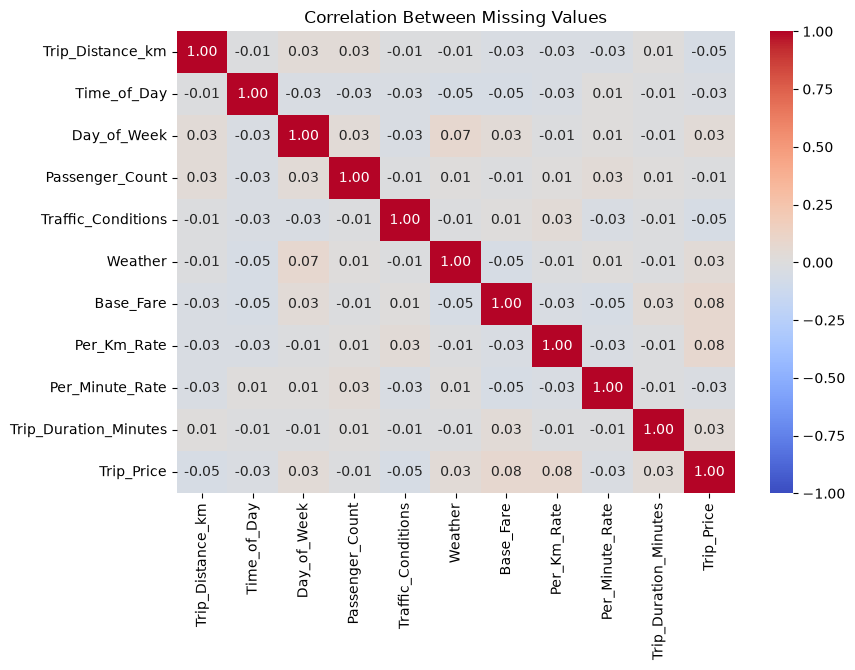

In [ ]:
#missing value correlation
missing_correlation = df.isnull().corr()

plt.figure(figsize=(9, 6))

sns.heatmap(
    missing_correlation,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f"
)

plt.title("Correlation Between Missing Values")
plt.show()

#### objective variable missing value

In [139]:
# Keep the original dataset unchanged
df_clean = df.copy()

print("Original shape:", df.shape)
print("Working copy shape:", df_clean.shape)

# Remove observations with missing target variable
df_clean = df_clean.dropna(subset=["Trip_Price"]).copy()

print("Original observations:", len(df))
print("Remaining observations:", len(df_clean))
print("Removed observations:", len(df) - len(df_clean))


missing_after = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing Percentage (%)": df_clean.isnull().mean() * 100
})

display(missing_after.round(2))

Original shape: (1000, 11)
Working copy shape: (1000, 11)
Original observations: 1000
Remaining observations: 951
Removed observations: 49


,Missing Count,Missing Percentage (%)
Trip_Distance_km,50,5.26
Time_of_Day,49,5.15
Day_of_Week,46,4.84
Passenger_Count,48,5.05
Traffic_Conditions,50,5.26
Weather,46,4.84
Base_Fare,44,4.63
Per_Km_Rate,44,4.63
Per_Minute_Rate,49,5.15
Trip_Duration_Minutes,46,4.84


In [140]:
# Compare descriptive statistics before and after removing observations with missing target values

# Before deletion
before = df.describe(include="all").T
before["median"] = df.median(numeric_only=True)

# After deletion
after = df_clean.describe(include="all").T
after["median"] = df_clean.median(numeric_only=True)

display(before)
display(after)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max,median
Trip_Distance_km,950.0,NaN,NaN,NaN,27.070547,19.9053,1.23,12.6325,25.83,38.405,146.067047,25.8300
Time_of_Day,950,4,Afternoon,371,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,950,2,Weekday,655,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger_Count,950.0,NaN,NaN,NaN,2.476842,1.102249,1.0,1.25,2.0,3.0,4.0,2.0000
Traffic_Conditions,950,3,Low,397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,950,3,Clear,667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base_Fare,950.0,NaN,NaN,NaN,3.502989,0.870162,2.01,2.73,3.52,4.26,5.0,3.5200
Per_Km_Rate,950.0,NaN,NaN,NaN,1.233316,0.429816,0.5,0.86,1.22,1.61,2.0,1.2200
Per_Minute_Rate,950.0,NaN,NaN,NaN,0.292916,0.115592,0.1,0.19,0.29,0.39,0.5,0.2900
Trip_Duration_Minutes,950.0,NaN,NaN,NaN,62.118116,32.154406,5.01,35.8825,61.86,89.055,119.84,61.8600


,count,unique,top,freq,mean,std,min,25%,50%,75%,max,median
Trip_Distance_km,901.0,NaN,NaN,NaN,27.190998,20.155134,1.23,12.63,25.87,38.68,146.067047,25.8700
Time_of_Day,902,4,Afternoon,351,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Day_of_Week,905,2,Weekday,622,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Passenger_Count,903.0,NaN,NaN,NaN,2.479513,1.100983,1.0,2.0,2.0,3.0,4.0,2.0000
Traffic_Conditions,901,3,Low,374,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Weather,905,3,Clear,634,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Base_Fare,907.0,NaN,NaN,NaN,3.4971,0.866729,2.01,2.73,3.51,4.23,5.0,3.5100
Per_Km_Rate,907.0,NaN,NaN,NaN,1.229934,0.429958,0.5,0.85,1.22,1.61,2.0,1.2200
Per_Minute_Rate,902.0,NaN,NaN,NaN,0.293902,0.115404,0.1,0.19,0.29,0.39,0.5,0.2900
Trip_Duration_Minutes,905.0,NaN,NaN,NaN,62.044144,32.321578,5.01,35.59,61.57,89.21,119.84,61.5700


#### predictor variables missing value

In [141]:
predictor_cols = [
    "Trip_Distance_km",
    "Time_of_Day",
    "Day_of_Week",
    "Passenger_Count",
    "Traffic_Conditions",
    "Weather",
    "Base_Fare",
    "Per_Km_Rate",
    "Per_Minute_Rate",
    "Trip_Duration_Minutes"
]

target_col = "Trip_Price"

# Count missing predictors for each observation
df_clean["Missing_Predictors"] = (
    df_clean[predictor_cols].isna().sum(axis=1)
)

missing_predictor_distribution = (
    df_clean["Missing_Predictors"]
    .value_counts()
    .sort_index()
)
display(missing_predictor_distribution)




Missing_Predictors
0    562
1    315
2     65
3      9
Name: count, dtype: int64

In [142]:
# Calculate overall predictor missing rate
n_before_predictor_removal = len(df_clean)

n_remove_ge2 = (        #missing predictors >= 2
    df_clean["Missing_Predictors"] >= 2
).sum()

n_remove_ge3 = (        #missing predictors >= 3
    df_clean["Missing_Predictors"] >= 3
).sum()

deletion_comparison = pd.DataFrame({
    "Deletion Rule": [
        "Remove >=2 Missing Predictors",
        "Remove >=3 Missing Predictors"
    ],
    
    "Observations Removed": [
        n_remove_ge2,
        n_remove_ge3
    ],
    
    "% of Usable-Y Sample": [
        n_remove_ge2 / n_before_predictor_removal * 100,
        n_remove_ge3 / n_before_predictor_removal * 100
    ],
    
    "% of Original Dataset": [
        n_remove_ge2 / len(df) * 100,
        n_remove_ge3 / len(df) * 100
    ]
})

print("Comparison of deletion strategies:")
display(deletion_comparison.round(2))

Comparison of deletion strategies:


,Deletion Rule,Observations Removed,% of Usable-Y Sample,% of Original Dataset
0,Remove >=2 Missing Predictors,74,7.78,7.4
1,Remove >=3 Missing Predictors,9,0.95,0.9


In [143]:
#Remove observations with >= 3 missing predictors
n_removed_ge3 = n_remove_ge3

df_clean = df_clean[
    df_clean["Missing_Predictors"] < 3
].copy()

n_after_predictor_removal = len(df_clean)

print("Observations before predictor-based removal:",
      n_before_predictor_removal)

print("Observations removed (>=3 missing predictors):",
      n_removed_ge3)

print("Observations remaining:",
      n_after_predictor_removal)

Observations before predictor-based removal: 951
Observations removed (>=3 missing predictors): 9
Observations remaining: 942


In [144]:
missing_summary = pd.DataFrame({
    "Missing Count":
        df_clean[predictor_cols]
        .isna()
        .sum()
})

missing_summary["Missing Rate (%)"] = (
    df_clean[predictor_cols]
    .isna()
    .mean()
    * 100
)

missing_summary = (
    missing_summary
    .sort_values(
        "Missing Count",
        ascending=False
    )
)

print("Missing values by predictor:")
display(missing_summary.round(2))

Missing values by predictor:


,Missing Count,Missing Rate (%)
Time_of_Day,48,5.10
Trip_Distance_km,47,4.99
Traffic_Conditions,47,4.99
Per_Minute_Rate,47,4.99
Weather,44,4.67
Passenger_Count,43,4.56
Trip_Duration_Minutes,43,4.56
Per_Km_Rate,43,4.56
Base_Fare,42,4.46
Day_of_Week,41,4.35


In [145]:
#The Missing_Predictors column is only used for data cleaning and will NOT be used as a regression predictor
df_clean = df_clean.drop(
    columns=["Missing_Predictors"]
)

print("Final dataset shape before imputation:",
      df_clean.shape)

Final dataset shape before imputation: (942, 11)


## train-test split

In [151]:
# Separate predictors and target
X = df_clean[predictor_cols].copy()
y = df_clean["Trip_Price"].copy()

# 80% training set / 20% testing set
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

# Check missing values after splitting
print("\nMissing values in training set:")
display(X_train.isna().sum())

print("\nMissing values in testing set:")
display(X_test.isna().sum())

Training set: (753, 10)
Testing set: (189, 10)

Missing values in training set:


Trip_Distance_km         40
Time_of_Day              33
Day_of_Week              30
Passenger_Count          31
Traffic_Conditions       40
Weather                  37
Base_Fare                38
Per_Km_Rate              31
Per_Minute_Rate          37
Trip_Duration_Minutes    34
dtype: int64


Missing values in testing set:


Trip_Distance_km          7
Time_of_Day              15
Day_of_Week              11
Passenger_Count          12
Traffic_Conditions        7
Weather                   7
Base_Fare                 4
Per_Km_Rate              12
Per_Minute_Rate          10
Trip_Duration_Minutes     9
dtype: int64

## Data imputation

In [153]:
# Missing Value Imputation
# Imputation values are calculated from TRAINING DATA only
# Test set is imputed using the same values as the training set


#Trip_Distance_km
#Use median because the distribution is strongly right-skewed


distance_median = X_train["Trip_Distance_km"].median()

X_train["Trip_Distance_km"] = (
    X_train["Trip_Distance_km"].fillna(distance_median)
)

X_test["Trip_Distance_km"] = (
    X_test["Trip_Distance_km"].fillna(distance_median)
)


#Passenger_Count
#Use mode because passenger count is a discrete variable

passenger_mode = X_train["Passenger_Count"].mode()[0]

X_train["Passenger_Count"] = (
    X_train["Passenger_Count"].fillna(passenger_mode)
)

X_test["Passenger_Count"] = (
    X_test["Passenger_Count"].fillna(passenger_mode)
)


#Approximately symmetric continuous variables
#Use mean imputation

mean_cols = [
    "Base_Fare",
    "Per_Km_Rate",
    "Per_Minute_Rate",
    "Trip_Duration_Minutes"
]

for col in mean_cols:

    train_mean = X_train[col].mean()

    X_train[col] = X_train[col].fillna(train_mean)
    X_test[col] = X_test[col].fillna(train_mean)


#Categorical variables
#Use the mode of the TRAINING SET

categorical_cols = [
    "Time_of_Day",
    "Day_of_Week",
    "Traffic_Conditions",
    "Weather"
]

for col in categorical_cols:

    train_mode = X_train[col].mode()[0]

    X_train[col] = X_train[col].fillna(train_mode)
    X_test[col] = X_test[col].fillna(train_mode)


#Validate imputation

print("Missing values in training set:")
display(X_train.isna().sum())

print("\nMissing values in testing set:")
display(X_test.isna().sum())

print(
    "\nTotal missing values in training set:",
    X_train.isna().sum().sum()
)

print(
    "Total missing values in testing set:",
    X_test.isna().sum().sum()
)

Missing values in training set:


Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
dtype: int64


Missing values in testing set:


Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
dtype: int64


Total missing values in training set: 0
Total missing values in testing set: 0


## dummy variable encoding

In [ ]:
categorical_cols = [
    "Time_of_Day",
    "Day_of_Week",
    "Traffic_Conditions",
    "Weather"
]

# Combine train and test temporarily for consistent encoding
# 對齊train set 跟 test set 的欄位

X_all = pd.concat([X_train, X_test])

# Convert categorical variables into dummy variables

X_all_encoded = pd.get_dummies(
    X_all,
    columns=categorical_cols,
    drop_first=True,            #選其中一個變數當基準，不然係數相加會變1 =>多重共線性問題
    dtype=int
)

# Split back into training and testing sets

X_train_encoded = X_all_encoded.loc[X_train.index].copy()
X_test_encoded = X_all_encoded.loc[X_test.index].copy()


# Check the result

print("Training set before encoding:", X_train.shape)
print("Training set after encoding:", X_train_encoded.shape)

print("\nTesting set before encoding:", X_test.shape)
print("Testing set after encoding:", X_test_encoded.shape)

print("\nVariables after dummy encoding:")
display(X_train_encoded.columns.tolist())

print("\nFirst 5 observations:")
display(X_train_encoded.head())

Training set before encoding: (753, 10)
Training set after encoding: (753, 14)

Testing set before encoding: (189, 10)
Testing set after encoding: (189, 14)

Variables after dummy encoding:


['Trip_Distance_km',
 'Passenger_Count',
 'Base_Fare',
 'Per_Km_Rate',
 'Per_Minute_Rate',
 'Trip_Duration_Minutes',
 'Time_of_Day_Evening',
 'Time_of_Day_Morning',
 'Time_of_Day_Night',
 'Day_of_Week_Weekend',
 'Traffic_Conditions_Low',
 'Traffic_Conditions_Medium',
 'Weather_Rain',
 'Weather_Snow']


First 5 observations:


,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Time_of_Day_Evening,Time_of_Day_Morning,Time_of_Day_Night,Day_of_Week_Weekend,Traffic_Conditions_Low,Traffic_Conditions_Medium,Weather_Rain,Weather_Snow
87,26.19,1.0,3.41,0.57,0.39,92.72,0,0,0,0,0,1,0,0
341,24.20,1.0,2.43,0.75,0.28,103.17,0,0,0,0,1,0,0,1
525,23.97,1.0,2.79,1.24,0.26,48.93,0,1,0,0,0,0,0,0
919,7.87,2.0,3.52,1.57,0.16,64.51,0,0,0,0,1,0,0,0
370,5.94,3.0,2.63,1.25,0.44,110.47,0,0,1,0,1,0,0,0


## multicollinearity analysis

In [155]:
# using VIF
# Training set only

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Add intercept for VIF calculation

X_vif = sm.add_constant(X_train_encoded)


# Calculate VIF for each predictor
vif_data = pd.DataFrame()

vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]


# Remove intercept from the displayed table

vif_data = vif_data[
    vif_data["Variable"] != "const"
].copy()

vif_data = vif_data.sort_values(
    "VIF",
    ascending=False
)

display(vif_data.round(3))

,Variable,VIF
11,Traffic_Conditions_Low,1.904
12,Traffic_Conditions_Medium,1.895
8,Time_of_Day_Morning,1.240
7,Time_of_Day_Evening,1.212
9,Time_of_Day_Night,1.130
13,Weather_Rain,1.036
1,Trip_Distance_km,1.035
14,Weather_Snow,1.028
4,Per_Km_Rate,1.027
10,Day_of_Week_Weekend,1.017


## muliple linear regression

In [158]:
# using Statsmodels
# for OLS regression and model performance evaluation

import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Add intercept
X_train_ols = sm.add_constant(X_train_encoded.astype(float))
X_test_ols = sm.add_constant(X_test_encoded.astype(float))

# Make sure test columns are identical to training columns
X_test_ols = X_test_ols.reindex(columns=X_train_ols.columns, fill_value=1)


# 2. Fit OLS model using training set
model = sm.OLS(y_train, X_train_ols).fit()


# 3. Display full regression results
print(model.summary())


# 4. Prediction
y_train_pred = model.predict(X_train_ols)
y_test_pred = model.predict(X_test_ols)


# 5. Model performance
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("\n===== Prediction Performance =====")
print("Training R² :", round(train_r2, 4))
print("Testing R²  :", round(test_r2, 4))
print("Testing MAE :", round(test_mae, 4))
print("Testing RMSE:", round(test_rmse, 4))

                            OLS Regression Results                            
Dep. Variable:             Trip_Price   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.868
Method:                 Least Squares   F-statistic:                     355.4
Date:                Wed, 30 Sep 2026   Prob (F-statistic):               0.00
Time:                        00:27:07   Log-Likelihood:                -3035.5
No. Observations:                 753   AIC:                             6101.
Df Residuals:                     738   BIC:                             6170.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

## residual diagnostics

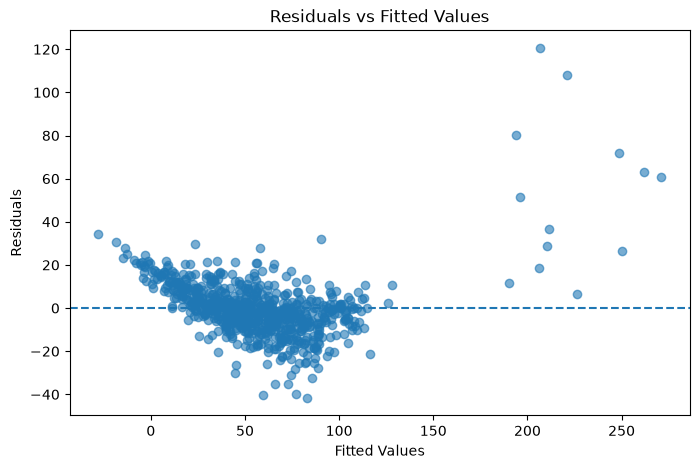

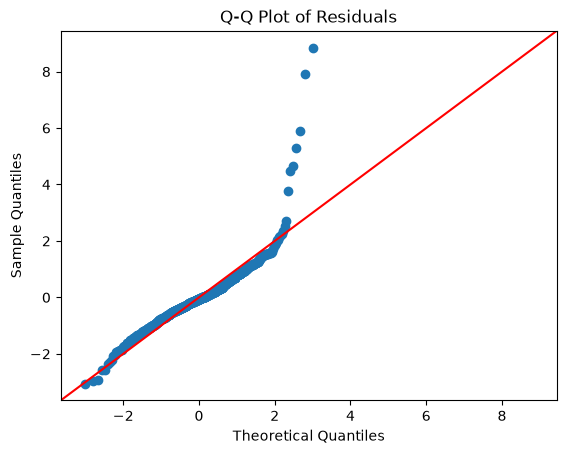

In [159]:
# ============================================================
# Residual Diagnostics
# ============================================================

import matplotlib.pyplot as plt
import statsmodels.api as sm

# Residuals and fitted values
residuals = model.resid
fitted_values = model.fittedvalues


# ------------------------------------------------------------
# 1. Residuals vs Fitted
# ------------------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    fitted_values,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")

plt.show()


# ------------------------------------------------------------
# 2. Q-Q Plot
# ------------------------------------------------------------

sm.qqplot(
    residuals,
    line="45",
    fit=True
)

plt.title("Q-Q Plot of Residuals")

plt.show()

### cook's distance

Cook's Distance threshold (4/n): 0.00531
Maximum Cook's Distance: 0.23754
Number above threshold: 29


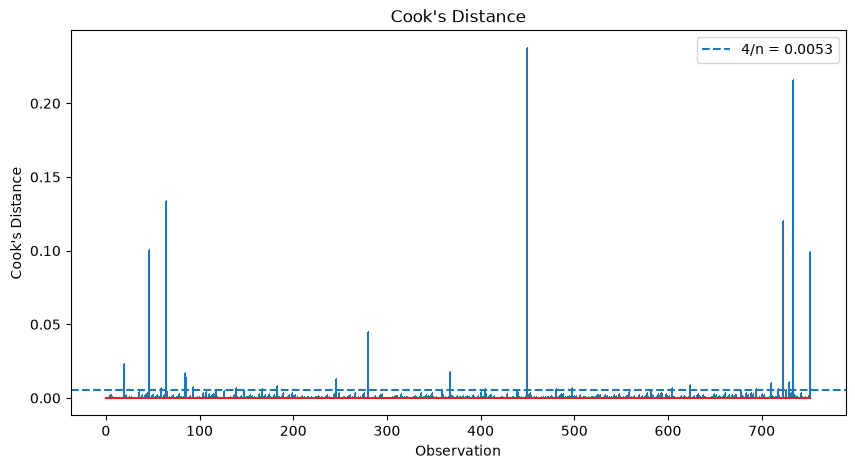

In [ ]:
# Influence Analysis - Cook's Distance

influence = model.get_influence()
cooks_d = influence.cooks_distance[0]

# Common reference threshold
threshold = 4 / len(X_train_ols)

print("Cook's Distance threshold (4/n):", round(threshold, 5))
print("Maximum Cook's Distance:", round(cooks_d.max(), 5))
print("Number above threshold:", (cooks_d > threshold).sum())



plt.figure(figsize=(10, 5))

plt.stem(
    np.arange(len(cooks_d)),
    cooks_d,
    markerfmt=","
)

plt.axhline(
    threshold,
    linestyle="--",
    label=f"4/n = {threshold:.4f}"
)

plt.xlabel("Observation")
plt.ylabel("Cook's Distance")
plt.title("Cook's Distance")
plt.legend()

plt.show()

In [161]:
# Find the 10 observations with the largest Cook's Distance

cook_table = pd.DataFrame({
    "Cook_Distance": cooks_d
}, index=X_train.index)

top10_cook = cook_table.sort_values(
    "Cook_Distance",
    ascending=False
).head(10)

top10_data = df_clean.loc[top10_cook.index].copy()
top10_data["Cook_Distance"] = top10_cook["Cook_Distance"]

display(
    top10_data.sort_values(
        "Cook_Distance",
        ascending=False
    )
)

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Cook_Distance
225,130.809001,Afternoon,Weekday,1.0,High,Clear,3.93,0.63,0.16,88.31,328.871769,0.237542
141,109.616082,Afternoon,Weekday,4.0,High,Clear,4.46,1.69,0.23,53.88,327.217665,0.215487
64,146.067047,Afternoon,Weekday,2.0,Medium,Clear,4.79,0.73,0.30,60.81,320.958664,0.133671
302,145.747060,Morning,Weekday,3.0,High,Rain,2.82,0.83,0.49,60.29,325.098950,0.120302
616,138.763887,Night,Weekday,2.0,High,Clear,3.98,1.71,0.39,74.32,332.043689,0.100248
110,102.747556,Evening,Weekday,2.0,Medium,Clear,2.23,1.80,0.23,53.09,274.535087,0.099345
588,122.820191,Afternoon,Weekday,NaN,High,Clear,4.13,0.96,0.12,30.98,247.598318,0.044494
338,116.667681,Morning,Weekday,2.0,High,Clear,3.81,0.74,0.25,110.82,248.295209,0.023042
268,139.062230,Afternoon,Weekday,2.0,Low,Rain,2.80,1.82,0.14,50.83,276.840597,0.017327
424,NaN,Night,Weekday,1.0,High,Clear,NaN,1.42,0.48,23.11,19.257200,0.017124


### log transform

                            OLS Regression Results                            
Dep. Variable:             Trip_Price   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.863
Method:                 Least Squares   F-statistic:                     338.3
Date:                Wed, 30 Sep 2026   Prob (F-statistic):          1.18e-309
Time:                        01:44:16   Log-Likelihood:                 138.43
No. Observations:                 753   AIC:                            -246.9
Df Residuals:                     738   BIC:                            -177.5
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

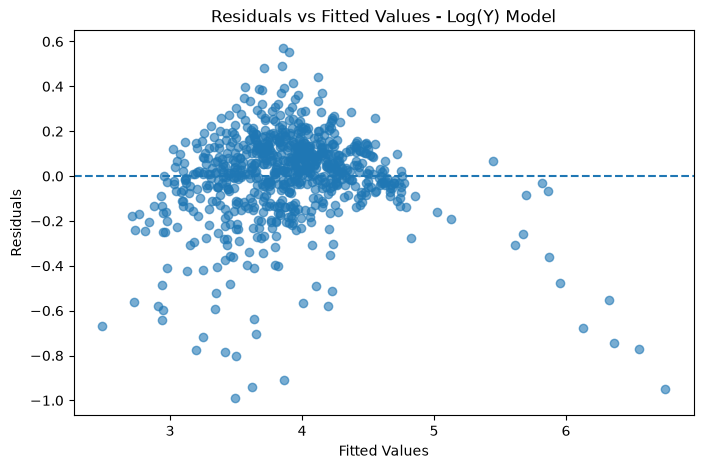

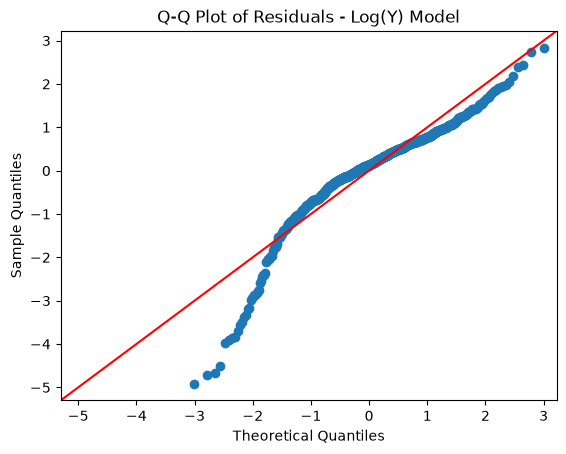

In [162]:
#對y進行Log轉換，並重新建立模型，檢查殘差分布是否改善

# 1. Log-transform Y
y_train_log = np.log(y_train)
y_test_log = np.log(y_test)

# 2. Fit OLS model
log_model = sm.OLS(y_train_log, X_train_ols).fit()

print(log_model.summary())

# Residual Diagnostics

log_residuals = log_model.resid
log_fitted = log_model.fittedvalues


# Residuals vs Fitted
plt.figure(figsize=(8, 5))
plt.scatter(log_fitted, log_residuals, alpha=0.6)
plt.axhline(0, linestyle="--")

plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values - Log(Y) Model")

plt.show()


# Q-Q Plot
sm.qqplot(log_residuals, line="45", fit=True)

plt.title("Q-Q Plot of Residuals - Log(Y) Model")
plt.show()


In [163]:
# Prediction on test set
y_test_log_pred = log_model.predict(X_test_ols)

# Transform prediction back to original price scale
y_test_pred_logmodel = np.exp(y_test_log_pred)

# Performance on original price scale
log_test_r2 = r2_score(y_test, y_test_pred_logmodel)
log_test_mae = mean_absolute_error(y_test, y_test_pred_logmodel)
log_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_logmodel)
)

print("Log Model Testing R² :", round(log_test_r2, 4))
print("Log Model Testing MAE :", round(log_test_mae, 4))
print("Log Model Testing RMSE:", round(log_test_rmse, 4))

Log Model Testing R² : -0.194
Log Model Testing MAE : 11.8058
Log Model Testing RMSE: 54.3629
